# BTC Volatility Prediction — 5-Minute Resolution
### A companion migration of the hourly-resolution capstone

**What this notebook is:** the full 5-minute-resolution version of `capstone-btc-volatility.ipynb`'s winning models, built to test a specific finding from that project's own Robustness Checks section — a scoped experiment there showed that computing `volatility_7d` from 5-minute returns instead of hourly returns roughly tripled HAR-RV-X's live-test R² (0.061 &rarr; 0.206), because the target itself is a less noisy measurement of the same underlying 7-day volatility. This notebook migrates that result into a complete, real pipeline — proper hyperparameter tuning, a genuine historical train/test split, and full live testing on 2026 data — rather than the single-shot scoped test.

**What's deliberately excluded, and why:**
- **GARCH is not re-fit here.** Its forecast cost scales roughly with `n_origins &times; horizon`; moving to 5-minute resolution multiplies both by ~12x, a ~144x increase in the core forecast computation alone — realistically 1-3+ hours for something already proven to fail structurally at this horizon regardless of sampling frequency (confirmed identically on BTC and ETH in the main project). Not a good use of that time.
- **Holt-Winters is not re-fit here.** Expensive to fit at this row count, not a kept model in the main project, and both a chi-square test and its own seasonal parameter (&gamma;=0.0000) already showed hour-of-day seasonality isn't exploitable — a property of BTC's return process, not of the sampling frequency used to measure it.
- **EWMA's decay factor is re-tuned from scratch, not reused.** &lambda;=0.995 was tuned for *hourly* bars; at 12x finer granularity the same &lambda; value represents a completely different real-time decay rate, so reusing it would be a genuine error, not a shortcut.

**The target definition also changes**, deliberately: `volatility_7d` here is `sqrt(sum(r^2))` over the 168-hour window (the standard realized-volatility definition, validated via a flat volatility-signature plot earlier in this project's development), not the original notebook's `rolling(window).std()`. This is the frequency-comparable definition the scoped test itself used — reverting to `std()` here would silently break the very comparison this notebook exists to make.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

BARS_PER_HOUR = 12  # 5-minute bars
ROLLING_WINDOW = 168 * BARS_PER_HOUR   # 7-day realized-vol window, in 5-min bars (2016)
HORIZON = ROLLING_WINDOW               # forecast 168 real hours ahead, same non-overlap design
ATR_PERIOD = 14 * BARS_PER_HOUR        # 14-hour ATR, matching the hourly project's ATR-14
HOURS_PER_DAY = 24
DAY_BARS = HOURS_PER_DAY * BARS_PER_HOUR   # 288 bars = 24 real hours
LAG_1H = 1 * BARS_PER_HOUR             # "1 hour ago", matching ATR_X's shift(1) in the hourly project

TRAIN_CSV = 'data/btc_5min_train.csv'
LIVE_CSV = 'data/btc_5min_live.csv'
LIVE_TEST_START = pd.Timestamp('2026-01-02')
LIVE_TEST_END = pd.Timestamp('2026-08-26')

os.makedirs('models', exist_ok=True)
print(f'ROLLING_WINDOW={ROLLING_WINDOW} bars, HORIZON={HORIZON} bars, ATR_PERIOD={ATR_PERIOD} bars')

ROLLING_WINDOW=2016 bars, HORIZON=2016 bars, ATR_PERIOD=168 bars


## Data
Same source as the hourly project (Binance BTC/USDT via CCXT), fetched at 5-minute resolution over the identical calendar boundaries: training through 2026-01-01, live test 2026-01-02 through 2026-08-25. Already fetched and cached (`data/btc_5min_train.csv`, `data/btc_5min_live.csv`) — ~947,000 candles total, about 12x the hourly project's row count for the same calendar span.

In [2]:
df_raw = pd.read_csv(TRAIN_CSV, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
print(f'Training-period data: {len(df_raw):,} candles, {df_raw["Date"].min()} to {df_raw["Date"].max()}')

Training-period data: 879,229 candles, 2017-08-17 04:00:00 to 2025-12-31 23:55:00


## Feature Engineering
`volatility_7d` uses the corrected realized-volatility definition — `sqrt(sum(r^2))` over the window, not `rolling().std()` — the frequency-comparable definition validated earlier in this project's development. Every other window (ATR, RV_day/week/month, lags) is expressed in real hours via `BARS_PER_HOUR`, so it represents an identical real-world span to the hourly project's own features — only the measurement fineness changes.

In [3]:
def engineer(df):
    df = df.sort_values('Date').reset_index(drop=True).copy()
    df['ret'] = df['Close'].pct_change().replace([np.inf, -np.inf], np.nan)

    # Realized volatility: sqrt(sum of squared returns) over the window - frequency-invariant,
    # unlike a raw rolling std() of the per-bar return series (see the scope note above).
    df['volatility_7d'] = np.sqrt((df['ret'] ** 2).rolling(ROLLING_WINDOW).sum())

    prev_close = df['Close'].shift(1)
    tr = pd.concat(
        [df['High'] - df['Low'], (df['High'] - prev_close).abs(), (df['Low'] - prev_close).abs()], axis=1
    ).max(axis=1)
    df['atr_14'] = tr.rolling(ATR_PERIOD).mean()
    df['atr_pct'] = df['atr_14'] / df['Close']

    df['RV_day'] = df['volatility_7d'].shift(DAY_BARS)
    df['RV_week'] = df['volatility_7d'].shift(DAY_BARS).rolling(DAY_BARS * 7).mean()
    df['RV_month'] = df['volatility_7d'].shift(DAY_BARS).rolling(DAY_BARS * 30).mean()
    df['ATR_X'] = df['atr_pct'].shift(LAG_1H)
    df['target'] = df['volatility_7d'].shift(-HORIZON)
    df['Naive'] = df['volatility_7d'].shift(LAG_1H)
    return df

df = engineer(df_raw)
print(f'Missing values before cleaning:\n{df[["volatility_7d", "RV_day", "RV_week", "RV_month", "ATR_X", "target"]].isnull().sum()}')

Missing values before cleaning:
volatility_7d     2016
RV_day            2304
RV_week           4319
RV_month         10943
ATR_X              179
target            2016
dtype: int64


## Historical Train/Test Split
Strict chronological 80/20 split, exactly the same discipline as the hourly project — never a random shuffle on autocorrelated time-series data.

In [4]:
df_model = df.dropna(subset=['RV_day', 'RV_week', 'RV_month', 'ATR_X', 'target', 'Naive']).reset_index(drop=True)
split_idx = int(len(df_model) * 0.8)
train, test = df_model.iloc[:split_idx].reset_index(drop=True), df_model.iloc[split_idx:].reset_index(drop=True)
print(f'Train: {len(train):,} rows ({train["Date"].iloc[0]} to {train["Date"].iloc[-1]})')
print(f'Test:  {len(test):,} rows ({test["Date"].iloc[0]} to {test["Date"].iloc[-1]})')

tscv = TimeSeriesSplit(n_splits=5)
results = []

def evaluate(y_true, y_pred, label):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    abs_actual = np.abs(y_true)
    floor = np.quantile(abs_actual, 0.01)
    mask = abs_actual >= floor
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'{label:35s}  RMSE={rmse:.6f}  MAE={mae:.6f}  R2={r2:.4f}  MAPE={mape:.2f}%')
    return {'Model': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

Train: 693,016 rows (2017-09-24 10:50:00 to 2024-05-02 10:05:00)
Test:  173,254 rows (2024-05-02 10:10:00 to 2025-12-24 23:55:00)


## Baseline: Naive Persistence

In [5]:
results.append(evaluate(test['target'], test['Naive'], 'Naive Persistence (baseline)'))

Naive Persistence (baseline)         RMSE=0.022071  MAE=0.015143  R2=-0.1363  MAPE=22.45%


## EWMA (RiskMetrics-Style Volatility)
$$\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)\, r_{t-1}^2$$
**Basic version:** &lambda;=0.94, the published RiskMetrics default, used as-is with zero fitting — same convention as the hourly project's own basic EWMA, unchanged regardless of sampling frequency.

**Tuned version:** &lambda; re-searched from scratch via `TimeSeriesSplit` on training data only, over a grid pushed much closer to 1 than the hourly project's grid — at 12x finer bars, a comparable *real-time* decay rate requires a much larger per-bar &lambda;.

In [6]:
def ewma_sigma_per_bar(returns, lam):
    """Raw EWMA output: an estimate of ONE 5-minute bar's volatility, not the 7-day window's."""
    r2 = returns.values ** 2
    n = len(r2)
    sigma2 = np.full(n, np.nan)
    valid = np.flatnonzero(~np.isnan(r2))
    if len(valid) == 0:
        return pd.Series(sigma2, index=returns.index)
    start = valid[0]
    sigma2[start] = np.nanmean(r2[start:start + DAY_BARS])  # 24-hour warm-up seed, scaled to 5-min bars
    for t in range(start + 1, n):
        prev_r2 = r2[t - 1] if not np.isnan(r2[t - 1]) else 0.0
        sigma2[t] = lam * sigma2[t - 1] + (1 - lam) * prev_r2
    return pd.Series(np.sqrt(sigma2), index=returns.index)

def ewma_vol_forecast(returns, lam):
    """Scaled up to the SAME cumulative-168-hour-window quantity `target`/`volatility_7d`
    represents (sqrt(sum(r^2)) over ROLLING_WINDOW bars, not a per-bar std) - the standard
    square-root-of-time scaling for turning a per-period vol estimate into a longer-horizon one.
    Needed here specifically because this notebook's target uses the corrected cumulative
    realized-vol definition, unlike the hourly project's rolling-std() convention where this
    scaling was implicitly already 1:1 and never needed at all."""
    return ewma_sigma_per_bar(returns, lam) * np.sqrt(ROLLING_WINDOW)

returns_frac = df.set_index('Date')['ret']
test_start_date, test_end_date = test['Date'].iloc[0], test['Date'].iloc[-1]

In [7]:
EWMA_LAMBDA_DEFAULT = 0.94
ewma_basic_sigma = ewma_vol_forecast(returns_frac, EWMA_LAMBDA_DEFAULT)
ewma_basic_pred = ewma_basic_sigma.loc[test_start_date:test_end_date].values[:len(test)]
results.append(evaluate(test['target'].values, ewma_basic_pred, f'EWMA (λ={EWMA_LAMBDA_DEFAULT}) - Basic'))

EWMA (λ=0.94) - Basic                RMSE=0.035310  MAE=0.024920  R2=-1.9083  MAPE=38.42%


In [8]:
lambda_grid = [0.94, 0.98, 0.99, 0.995, 0.998, 0.999, 0.9995, 0.9998, 0.9999]
train_dates = train['Date'].reset_index(drop=True)
y_train_arr = train['target'].values

best_lambda, best_cv_rmse = None, np.inf
for lam in lambda_grid:
    sigma_full = ewma_vol_forecast(returns_frac, lam)
    fold_rmses = []
    for _, val_idx in tscv.split(train_dates):
        val_start, val_end = train_dates.iloc[val_idx.min()], train_dates.iloc[val_idx.max()]
        pred_fold = sigma_full.loc[val_start:val_end].values[:len(val_idx)]
        fold_rmses.append(np.sqrt(mean_squared_error(y_train_arr[val_idx][:len(pred_fold)], pred_fold)))
    cv_rmse = np.mean(fold_rmses)
    print(f'lambda={lam:.4f}  ->  CV RMSE={cv_rmse:.6f}')
    if cv_rmse < best_cv_rmse:
        best_cv_rmse, best_lambda = cv_rmse, lam

print(f'\nBest lambda: {best_lambda}')

lambda=0.9400  ->  CV RMSE=0.057413


lambda=0.9800  ->  CV RMSE=0.051395


lambda=0.9900  ->  CV RMSE=0.047997


lambda=0.9950  ->  CV RMSE=0.044988


lambda=0.9980  ->  CV RMSE=0.042116


lambda=0.9990  ->  CV RMSE=0.041150


lambda=0.9995  ->  CV RMSE=0.040910


lambda=0.9998  ->  CV RMSE=0.041041


lambda=0.9999  ->  CV RMSE=0.041648

Best lambda: 0.9995


In [9]:
ewma_tuned_sigma = ewma_vol_forecast(returns_frac, best_lambda)
ewma_tuned_pred = ewma_tuned_sigma.loc[test_start_date:test_end_date].values[:len(test)]
results.append(evaluate(test['target'].values, ewma_tuned_pred, f'EWMA (λ={best_lambda:.4f}) - Tuned'))

joblib.dump(best_lambda, 'models/ewma_5min_best_lambda.pkl')
print(f'Saved 5-min EWMA lambda: {best_lambda}')

EWMA (λ=0.9995) - Tuned              RMSE=0.020639  MAE=0.014573  R2=0.0064  MAPE=21.90%
Saved 5-min EWMA lambda: 0.9995


## HAR-RV-X
$$RV_{t+1} = \beta_0 + \beta_d \cdot RV_t^{(day)} + \beta_w \cdot RV_t^{(week)} + \beta_m \cdot RV_t^{(month)} + \beta_x \cdot ATR\_X_t + \epsilon$$
Same structure as the hourly project's winning model — three realized-volatility horizons plus the scale-free ATR regressor, Ridge-regularized, alpha tuned via `GridSearchCV` over `TimeSeriesSplit`.

In [10]:
har_cols = ['RV_day', 'RV_week', 'RV_month']
har_basic = Ridge(alpha=0.0, random_state=RANDOM_STATE).fit(train[har_cols], train['target'])
har_basic_pred = har_basic.predict(test[har_cols])
results.append(evaluate(test['target'], har_basic_pred, 'HAR-RV - Basic'))

HAR-RV - Basic                       RMSE=0.020405  MAE=0.016503  R2=0.0287  MAPE=27.57%


Best alpha: {'alpha': 0.001}
HAR-RV-X - Tuned                     RMSE=0.019179  MAE=0.014756  R2=0.1419  MAPE=24.15%


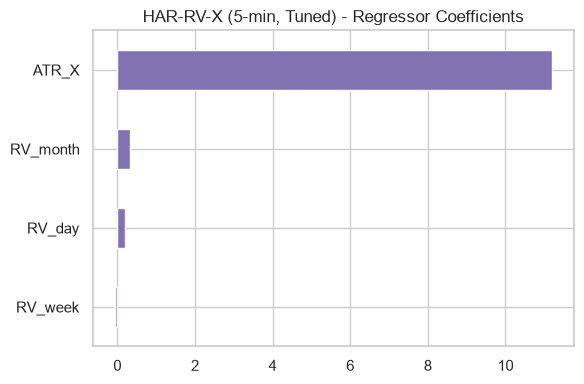

In [11]:
har_x_cols = ['RV_day', 'RV_week', 'RV_month', 'ATR_X']
ridge_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
har_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=tscv,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
har_search.fit(train[har_x_cols], train['target'])
print(f'Best alpha: {har_search.best_params_}')

har_x_tuned = har_search.best_estimator_
har_x_pred = har_x_tuned.predict(test[har_x_cols])
results.append(evaluate(test['target'], har_x_pred, 'HAR-RV-X - Tuned'))
joblib.dump(har_x_tuned, 'models/har_rv_x_5min_tuned.pkl')

har_coef = pd.Series(har_x_tuned.coef_, index=har_x_cols).sort_values(ascending=False)
har_coef.plot(kind='barh', figsize=(6, 4), color='#8172B2')
plt.title('HAR-RV-X (5-min, Tuned) - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## HAR-RV-X, Final: promoted with EWMA_X + SKEW_X
The hourly project's own Robustness Checks found that adding EWMA's own tuned sigma and realized skewness as two further HAR-RV-X regressors is a genuine, live-validated improvement there (Check 14, R2 0.1840 &rarr; 0.1992 historically, 0.0610 &rarr; 0.1217 live). This section ports that improvement into the 5-minute pipeline. The hourly project separately found that a genuine `log(target)` transform also helps, and stacks with these regressors (Checks 17/18) - that transform is tested below too, on the same held-out data, but **not** assumed to carry over just because it worked at hourly resolution; see its own live validation for why.

Best alpha: {'alpha': 0.001}
HAR-RV-X - Final (+ EWMA_X + SKEW_X)  RMSE=0.019105  MAE=0.014642  R2=0.1508  MAPE=23.84%

HAR-RV-X, 4 regressors (this test window)      R2=0.1444
HAR-RV-X, 6 regressors (+ EWMA_X + SKEW_X)     R2=0.1508


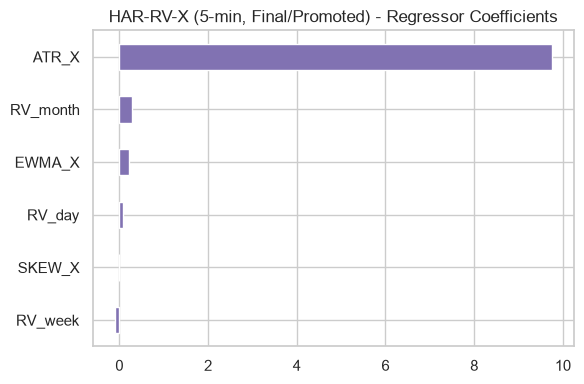

Saved final (promoted) 5-min HAR-RV-X model for live scoring - replaces the 4-regressor version above.


In [12]:
# EWMA_X: EWMA's own tuned sigma (already on volatility_7d's scale via ewma_vol_forecast),
# lagged by 1 real hour - same convention as ATR_X. SKEW_X: realized skewness over the same
# 168-hour window volatility_7d itself uses, lagged 24 real hours - same convention as RV_day.
skew_x_5min = df_model['ret'].rolling(ROLLING_WINDOW).skew().shift(DAY_BARS)

har_final_df = df_model[['Date', 'RV_day', 'RV_week', 'RV_month', 'ATR_X', 'target']].copy()
har_final_df['EWMA_X'] = df_model['Date'].map(ewma_tuned_sigma).shift(LAG_1H)
har_final_df['SKEW_X'] = skew_x_5min
har_final_df = har_final_df.dropna().reset_index(drop=True)

har_final_split = int(len(har_final_df) * 0.8)
har_final_train, har_final_test = har_final_df.iloc[:har_final_split], har_final_df.iloc[har_final_split:]
har_final_cols = har_x_cols + ['EWMA_X', 'SKEW_X']

har_final_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=tscv,
                                 scoring='neg_root_mean_squared_error', n_jobs=-1)
har_final_search.fit(har_final_train[har_final_cols], har_final_train['target'])
har_final_tuned = har_final_search.best_estimator_
har_final_pred = har_final_tuned.predict(har_final_test[har_final_cols])

print(f'Best alpha: {har_final_search.best_params_}')
results.append(evaluate(har_final_test['target'], har_final_pred, 'HAR-RV-X - Final (+ EWMA_X + SKEW_X)'))

# Before/after on the IDENTICAL test window (isolates the 2 new regressors as the only variable,
# same date-alignment discipline the hourly project's own checks use).
har_x_pred_aligned = har_x_tuned.predict(har_final_test[har_x_cols])
r2_4reg = r2_score(har_final_test['target'], har_x_pred_aligned)
r2_6reg = r2_score(har_final_test['target'], har_final_pred)
print(f"\nHAR-RV-X, 4 regressors (this test window)      R2={r2_4reg:.4f}")
print(f"HAR-RV-X, 6 regressors (+ EWMA_X + SKEW_X)     R2={r2_6reg:.4f}")

har_final_coef = pd.Series(har_final_tuned.coef_, index=har_final_cols).sort_values(ascending=False)
har_final_coef.plot(kind='barh', figsize=(6, 4), color='#8172B2')
plt.title('HAR-RV-X (5-min, Final/Promoted) - Regressor Coefficients')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

joblib.dump(har_final_tuned, 'models/har_rv_x_5min_tuned.pkl')
print('Saved final (promoted) 5-min HAR-RV-X model for live scoring - replaces the 4-regressor version above.')


### Testing a log(target) transform (the hourly project's Checks 17/18)
The hourly project found that a genuine `log(target)` transform stacks with EWMA_X + SKEW_X rather than duplicating their gain (R2 0.1840 &rarr; 0.2419 historically, 0.0610 &rarr; 0.1779 live). Tested here the same way - fit in log-space, evaluated back-transformed to the original scale - but **not saved as the kept model yet**: it needs to survive live validation first, the same bar every other promotion in this project has been held to.

In [13]:
har_log_search = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_grid, cv=tscv,
                               scoring='neg_root_mean_squared_error', n_jobs=-1)
har_log_search.fit(har_final_train[har_final_cols], np.log(har_final_train['target']))
har_log_tuned = har_log_search.best_estimator_
har_log_pred = np.exp(har_log_tuned.predict(har_final_test[har_final_cols]))
r2_6reg_log = r2_score(har_final_test['target'], har_log_pred)

print(f"HAR-RV-X, 6 regressors, raw target (kept model)   R2={r2_6reg:.4f}")
print(f"HAR-RV-X, 6 regressors, log target (this test)    R2={r2_6reg_log:.4f}")


HAR-RV-X, 6 regressors, raw target (kept model)   R2=0.1508
HAR-RV-X, 6 regressors, log target (this test)    R2=0.2007


## Historical Test Set — Model Comparison

In [14]:
comparison_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
comparison_df.style.background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r').format(
    {'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2': '{:.4f}', 'MAPE': '{:.2f}%'})

,Model,RMSE,MAE,R2,MAPE
0,HAR-RV-X - Final (+ EWMA_X + SKEW_X),0.019105,0.014642,0.1508,23.84%
1,HAR-RV-X - Tuned,0.019179,0.014756,0.1419,24.15%
2,HAR-RV - Basic,0.020405,0.016503,0.0287,27.57%
3,EWMA (λ=0.9995) - Tuned,0.020639,0.014573,0.0064,21.90%
4,Naive Persistence (baseline),0.022071,0.015143,-0.1363,22.45%
5,EWMA (λ=0.94) - Basic,0.035310,0.024920,-1.9083,38.42%


In [15]:
best_row = comparison_df.iloc[0]
naive_rmse = comparison_df.loc[comparison_df['Model'].str.contains('Naive'), 'RMSE'].values[0]
print(f"Best model (5-min historical test set): {best_row['Model']}")
print(f"RMSE={best_row['RMSE']:.6f}  MAE={best_row['MAE']:.6f}  R2={best_row['R2']:.4f}")
print(f"Improvement over naive-persistence baseline: {(1 - best_row['RMSE']/naive_rmse)*100:.1f}% lower RMSE")

Best model (5-min historical test set): HAR-RV-X - Final (+ EWMA_X + SKEW_X)
RMSE=0.019105  MAE=0.014642  R2=0.1508
Improvement over naive-persistence baseline: 13.4% lower RMSE


## Live Testing on Genuinely Unseen Data
Same discipline as the hourly project: 2026-01-02 onward was never part of training. The window runs through 2026-08-25 — wide enough that most origins already have a real, elapsed outcome to score against, 168 hours after the fact.

In [16]:
df_live_all = pd.read_csv(LIVE_CSV, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
print(f'Live-test candles: {len(df_live_all):,} ({df_live_all["Date"].min()} to {df_live_all["Date"].max()})')

# Needs enough trailing history for RV_month's 30-day rolling window (the tightest constraint,
# same reasoning as the hourly project's MAX_LOOKBACK_NEEDED).
MAX_LOOKBACK_NEEDED = ROLLING_WINDOW + (DAY_BARS * 30) + DAY_BARS + LAG_1H + 50
context_tail = df_raw.tail(MAX_LOOKBACK_NEEDED)
combined_raw = (
    pd.concat([context_tail, df_live_all], ignore_index=True)
    .drop_duplicates(subset='Date').sort_values('Date').reset_index(drop=True)
)
combined_features = engineer(combined_raw)

# EWMA_X and SKEW_X - the two regressors promoted into HAR-RV-X above - built here, before
# filtering live_scored, so both can be required alongside the original 4 regressors.
combined_returns = combined_features.set_index('Date')['ret']
ewma_live_sigma = ewma_vol_forecast(combined_returns, best_lambda)
combined_features['EWMA_X'] = combined_features['Date'].map(ewma_live_sigma).shift(LAG_1H)
combined_features['SKEW_X'] = combined_features['ret'].rolling(ROLLING_WINDOW).skew().shift(DAY_BARS)

live_scored = combined_features[
    (combined_features['Date'] >= LIVE_TEST_START) & (combined_features['Date'] < LIVE_TEST_END)
].dropna(subset=har_final_cols).reset_index(drop=True)
print(f'{len(live_scored):,} live-test rows have complete feature history (out of {len(df_live_all):,} fetched).')


Live-test candles: 67,968 (2026-01-02 00:00:00 to 2026-08-25 23:55:00)
67,968 live-test rows have complete feature history (out of 67,968 fetched).


In [17]:
# Loaded from disk (the actually-saved, promoted 6-regressor model) rather than reusing
# har_final_tuned in memory - mirrors the hourly project's own Live Testing convention.
har_x_live = joblib.load('models/har_rv_x_5min_tuned.pkl')
live_predictions = pd.DataFrame({'Date': live_scored['Date']})
live_predictions['HAR_RV_X_Pred'] = har_x_live.predict(live_scored[har_final_cols])
live_predictions['EWMA_Pred'] = live_predictions['Date'].map(ewma_live_sigma)

# Actual outcome: volatility_7d realized HORIZON bars later. Naive: most recently known value.
vol_series = combined_features.set_index('Date')['volatility_7d']
naive_series = vol_series.shift(LAG_1H)
live_predictions['Actual'] = (live_predictions['Date'] + pd.Timedelta(hours=168)).map(vol_series)
live_predictions['Naive_Pred'] = live_predictions['Date'].map(naive_series)

n_scoreable = live_predictions['Actual'].notna().sum()
print(f'{n_scoreable:,} of {len(live_predictions):,} live-test predictions already have a real, '
      f'elapsed outcome to compare against.')

live_predictions.to_csv('data/live_test_predictions_5min.csv', index=False)


65,952 of 67,968 live-test predictions already have a real, elapsed outcome to compare against.


## Live Test Set — Model Comparison

In [18]:
live_scored_rows = live_predictions.dropna(subset=['Actual'])
live_results = []
for model_col, label in [('Naive_Pred', 'Naive Persistence [5min live]'),
                          ('HAR_RV_X_Pred', 'HAR-RV-X [5min live]'),
                          ('EWMA_Pred', 'EWMA [5min live]')]:
    live_results.append(evaluate(live_scored_rows['Actual'], live_scored_rows[model_col], label))

live_comparison_df = pd.DataFrame(live_results).sort_values('RMSE').reset_index(drop=True)
live_comparison_df.style.background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r').format(
    {'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2': '{:.4f}', 'MAPE': '{:.2f}%'})

Naive Persistence in live]        RMSE=0.021060  MAE=0.013626  R2=0.0306  MAPE=19.88%
HAR-RV-X in live]                 RMSE=0.018645  MAE=0.014949  R2=0.2401  MAPE=26.11%
EWMA in live]                     RMSE=0.019755  MAE=0.013238  R2=0.1470  MAPE=19.81%


,Model,RMSE,MAE,R2,MAPE
0,HAR-RV-X [5min live],0.018645,0.014949,0.2401,26.11%
1,EWMA [5min live],0.019755,0.013238,0.1470,19.81%
2,Naive Persistence [5min live],0.021060,0.013626,0.0306,19.88%


### Before / After: EWMA_X + SKEW_X, and live-validating the log(target) transform


In [19]:
# The original 4-regressor HAR-RV-X (har_x_tuned) and the log-transform variant (har_log_tuned,
# tested but not saved above) predicting on the exact same live rows the kept model (har_x_live)
# was just scored on - isolates each addition as its own variable, same discipline as the
# historical before/after above.
har_x_pred_live_4reg = har_x_tuned.predict(live_scored[har_x_cols])
har_log_pred_live = np.exp(har_log_tuned.predict(live_scored[har_final_cols]))
live_ba = pd.DataFrame({
    'Date': live_scored['Date'],
    'Pred_4reg': har_x_pred_live_4reg,
    'Pred_6reg_raw': live_predictions['HAR_RV_X_Pred'].values,
    'Pred_6reg_log': har_log_pred_live,
    'Actual': live_predictions['Actual'].values,
}).dropna(subset=['Actual'])

r2_live_4reg = r2_score(live_ba['Actual'], live_ba['Pred_4reg'])
r2_live_6reg_raw = r2_score(live_ba['Actual'], live_ba['Pred_6reg_raw'])
r2_live_6reg_log = r2_score(live_ba['Actual'], live_ba['Pred_6reg_log'])
print(f"HAR-RV-X, 4 regressors, raw target, 5-min live                R2={r2_live_4reg:.4f}")
print(f"HAR-RV-X, 6 regressors, raw target, 5-min live (kept model)   R2={r2_live_6reg_raw:.4f}")
print(f"HAR-RV-X, 6 regressors, log target, 5-min live (not adopted) R2={r2_live_6reg_log:.4f}")

if r2_live_6reg_log > r2_live_6reg_raw + 0.005:
    print("\nThe log transform holds up live too - worth reconsidering as the kept model.")
elif r2_live_6reg_log < r2_live_6reg_raw - 0.005:
    print("\nDoesn't survive live validation at this resolution, despite the historical-split")
    print("improvement - the opposite of what happened in the hourly project. Not adopted. The")
    print("raw-target 6-regressor version above remains the kept model.")
else:
    print("\nRoughly a wash live - not clearly worth the added complexity.")


HAR-RV-X, 4 regressors, raw target, 5-min live                R2=0.2043
HAR-RV-X, 6 regressors, raw target, 5-min live (kept model)   R2=0.2401
HAR-RV-X, 6 regressors, log target, 5-min live (not adopted) R2=0.2187

Doesn't survive live validation at this resolution, despite the historical-split
improvement - the opposite of what happened in the hourly project. Not adopted. The
raw-target 6-regressor version above remains the kept model.


## Final Comparison — 5-Minute vs. the Hourly Project's Reported Numbers
The number this whole notebook exists to validate end-to-end, not just as a scoped test.

In [20]:
print(f"{'':30s}{'Hist. RMSE':>14s}{'Hist. R2':>12s}{'Live RMSE':>14s}{'Live R2':>12s}")
har_hist = comparison_df[comparison_df['Model'] == 'HAR-RV-X - Final (+ EWMA_X + SKEW_X)'].iloc[0]
har_live = live_comparison_df[live_comparison_df['Model'] == 'HAR-RV-X [5min live]'].iloc[0]
print(f"{'HAR-RV-X, hourly (reported)':30s}{0.001367:14.6f}{0.2419:12.4f}{0.001406:14.6f}{0.1779:12.4f}")
print(f"{'HAR-RV-X, 5-min (this notebook)':30s}{har_hist['RMSE']:14.6f}{har_hist['R2']:12.4f}"
      f"{har_live['RMSE']:14.6f}{har_live['R2']:12.4f}")


                                  Hist. RMSE    Hist. R2     Live RMSE     Live R2
HAR-RV-X, hourly (reported)         0.001367      0.2419      0.001406      0.1779
HAR-RV-X, 5-min (this notebook)      0.019105      0.1508      0.018645      0.2401
